# LSTM — session **side** (gap + prior session)

Two forecasts per day at session open:

- **London:** 08:00–14:30 `Europe/London`
- **NYC:** 09:30–16:00 `America/New_York`

Signed MSE and the mag head both collapsed side skill (test dir ≤ always-long). This run is **side only** (BCE). Size for touch/sim is the **train median** range, not a second head.

**New inputs known at open (no leak):** 5-d log returns, plus tiled `is_nyc`, overnight/session **gap** `log(open / prior session close)`, **prior session** signed dominant move, lookback **log range**.

Score **dom_side vs always-long, gap-follow, and prior-session-follow**. If the LSTM cannot beat those, the extra net is not helping.

Weights: `models/lstm/`.


In [89]:
# Start .venv in terminal
# ----------------------
# .\.venv\Scripts\activate
# python -m ipykernel install --user --name=.venv --display-name "Python (.venv)"
# ----------------------


In [90]:
import json
import os
import random
import sys
from datetime import time
from pathlib import Path

_ROOT = Path.cwd() if (Path.cwd() / "Data_Handling.py").exists() else Path.cwd().parent
if not (_ROOT / "Data_Handling.py").exists() and (Path.cwd() / "Mario" / "Data_Handling.py").exists():
    _ROOT = Path.cwd() / "Mario"
if not (_ROOT / "Data_Handling.py").exists() and (Path.cwd().parent / "Mario" / "Data_Handling.py").exists():
    _ROOT = Path.cwd().parent / "Mario"
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM
from tensorflow.keras.models import Sequential

from Data_Handling import fetch_alpaca_vbt_data

np.random.seed(SEED)
tf.random.set_seed(SEED)


In [ ]:
SYMBOL = "SPY"
START = "2022-01-01"
END = "2026-05-01"
TIMEFRAME_UNIT = "Minute"
MULTIPLIER = 5

WINDOW = 156
EPOCHS = 50
BATCH_SIZE = 32
PATIENCE = 8
EMBARGO = 4

FEATURES = "logret_gap_prevdom"
N_FEATS = 9  # 5 logrets + is_nyc, gap, prev_dom, lookback_range
TARGET = "session_side_bce"
DROPOUT = 0.3

SESSIONS = (
    {"name": "london", "tz": "Europe/London", "open": time(8, 0), "close": time(14, 30)},
    {"name": "nyc", "tz": "America/New_York", "open": time(9, 30), "close": time(16, 0)},
)

MODEL_DIR = _ROOT / "models" / "lstm"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "model.h5"
SCALER_PATH = MODEL_DIR / "scaler.json"
TARGET_SCALER_PATH = MODEL_DIR / "target_scaler.json"


In [92]:
df = fetch_alpaca_vbt_data(
    symbol=SYMBOL,
    start=START,
    end=END,
    timeframe_unit=TIMEFRAME_UNIT,
    multiplier=MULTIPLIER,
)
ohlcv = df[["Open", "High", "Low", "Close", "Volume"]].to_numpy(dtype=np.float64)
print(df.tail())
print(f"bars={len(df):,}  {df.index.min()} → {df.index.max()}")


field                          Open      High     Low    Close   Volume
timestamp                                                              
2026-04-30 23:35:00+00:00  720.1400  720.2500  720.13  720.130   5681.0
2026-04-30 23:40:00+00:00  720.1410  720.1500  720.01  720.010   6311.0
2026-04-30 23:45:00+00:00  719.9600  720.1300  719.96  720.051   2490.0
2026-04-30 23:50:00+00:00  720.0999  720.1932  719.89  719.890   3484.0
2026-04-30 23:55:00+00:00  719.9300  719.9700  719.60  719.870  13457.0
bars=87,119  2024-07-01 08:00:00+00:00 → 2026-04-30 23:55:00+00:00


## Session samples

OHLCV log-return windows **before** the open bar, plus leak-free context tiled on every timestep. Label = sign of the larger high/low excursion from open.


In [93]:
if "ohlcv" not in globals() or "df" not in globals():
    df = fetch_alpaca_vbt_data(
        symbol=SYMBOL,
        start=START,
        end=END,
        timeframe_unit=TIMEFRAME_UNIT,
        multiplier=MULTIPLIER,
    )
    ohlcv = df[["Open", "High", "Low", "Close", "Volume"]].to_numpy(dtype=np.float64)
    print(f"bars={len(df):,}  {df.index.min()} → {df.index.max()}")


def ohlcv_to_log_features(ohlcv: np.ndarray) -> np.ndarray:
    o, h, l, c, v = (ohlcv[:, i] for i in range(5))
    c_prev = np.empty_like(c)
    c_prev[0] = c[0]
    c_prev[1:] = c[:-1]
    v_prev = np.empty_like(v)
    v_prev[0] = np.maximum(v[0], 1.0)
    v_prev[1:] = np.maximum(v[:-1], 1.0)
    c_prev = np.maximum(c_prev, 1e-12)
    v = np.maximum(v, 1.0)
    return np.stack(
        [
            np.log(o / c_prev),
            np.log(h / c_prev),
            np.log(l / c_prev),
            np.log(c / c_prev),
            np.log(v / v_prev),
        ],
        axis=1,
    )


def session_mask(index: pd.DatetimeIndex, tz: str, day, open_t, close_t) -> np.ndarray:
    local = index.tz_convert(tz)
    start = pd.Timestamp.combine(day, open_t).tz_localize(tz)
    end = pd.Timestamp.combine(day, close_t).tz_localize(tz)
    return (local >= start) & (local < end)


def make_session_samples(df: pd.DataFrame, ohlcv: np.ndarray, window: int):
    feats = ohlcv_to_log_features(ohlcv)
    index = df.index
    rows = []
    t_open = []

    for spec in SESSIONS:
        tz = spec["tz"]
        local = index.tz_convert(tz)
        days = pd.Index(local.date).unique()
        for day in days:
            mask = session_mask(index, tz, day, spec["open"], spec["close"])
            idx = np.flatnonzero(mask)
            if len(idx) < 6:
                continue
            open_i, close_i = int(idx[0]), int(idx[-1])
            if open_i < window:
                continue
            o = float(ohlcv[open_i, 0])
            h = float(np.max(ohlcv[idx, 1]))
            l = float(np.min(ohlcv[idx, 2]))
            c = float(ohlcv[close_i, 3])
            if not (o > 0 and h > 0 and l > 0 and c > 0):
                continue
            up = h / o - 1.0
            dn = 1.0 - l / o
            y = up if up >= dn else -dn
            t_open.append(open_i)
            rows.append(
                {
                    "session": spec["name"],
                    "open_i": open_i,
                    "close_i": close_i,
                    "open_time": index[open_i],
                    "close_time": index[close_i],
                    "open": o,
                    "high": h,
                    "low": l,
                    "close": c,
                    "up_ext": up,
                    "dn_ext": dn,
                    "y_dom": y,
                    "y_oc": np.log(c / o),
                }
            )

    meta = pd.DataFrame(rows).sort_values("open_i").reset_index(drop=True)
    prev_close = meta["close"].shift(1)
    meta["gap"] = np.log(meta["open"] / np.maximum(prev_close, 1e-12))
    meta["prev_dom"] = meta["y_dom"].shift(1)
    meta["is_nyc"] = (meta["session"] == "nyc").astype(np.float64)
    meta.loc[0, ["gap", "prev_dom"]] = 0.0

    Xs = []
    for rec in meta.itertuples():
        oi = int(rec.open_i)
        win = feats[oi - window : oi]
        hi = float(np.max(ohlcv[oi - window : oi, 1]))
        lo = float(np.min(ohlcv[oi - window : oi, 2]))
        lb_range = float(np.log(max(hi, 1e-12) / max(lo, 1e-12)))
        extra = np.array([rec.is_nyc, rec.gap, rec.prev_dom, lb_range], dtype=np.float64)
        extra = np.broadcast_to(extra, (window, 4))
        Xs.append(np.concatenate([win, extra], axis=1))

    X = np.stack(Xs, axis=0)
    y = meta["y_dom"].to_numpy(dtype=np.float64)
    t = meta["open_i"].to_numpy(dtype=np.int64)
    return X, y, t, meta


def chrono_split_embargo(n: int, train_frac: float = 0.70, val_frac: float = 0.15, embargo: int = 0):
    i70 = int(train_frac * n)
    i85 = int((train_frac + val_frac) * n)
    return slice(0, i70), slice(i70 + embargo, i85), slice(i85 + embargo, n)


def side_acc(pred_sign, y):
    return float(np.mean(np.sign(pred_sign) == np.sign(y)))


X_all, y_all, t_all, meta_all = make_session_samples(df, ohlcv, WINDOW)
assert X_all.shape[1:] == (WINDOW, N_FEATS), X_all.shape
print(f"X_all {X_all.shape}  features={FEATURES}")
print(f"samples={len(y_all)}\n{meta_all['session'].value_counts().to_string()}")
print(f"P(upside dominant)={float((y_all > 0).mean()):.3f}  median |y|={float(np.median(np.abs(y_all))):.4%}")

train_sl, val_sl, test_sl = chrono_split_embargo(len(X_all), embargo=EMBARGO)
X_train, y_train, t_train = X_all[train_sl], y_all[train_sl], t_all[train_sl]
X_val, y_val, t_val = X_all[val_sl], y_all[val_sl], t_all[val_sl]
X_test, y_test, t_test = X_all[test_sl], y_all[test_sl], t_all[test_sl]
meta_train, meta_val, meta_test = (
    meta_all.iloc[train_sl].copy(),
    meta_all.iloc[val_sl].copy(),
    meta_all.iloc[test_sl].copy(),
)
print(f"split: {len(X_train)} / {len(X_val)} / {len(X_test)}  embargo={EMBARGO}")

for name, y, meta in (("train", y_train, meta_train), ("val", y_val, meta_val), ("test", y_test, meta_test)):
    always = float((y > 0).mean())
    gap_f = side_acc(meta["gap"].to_numpy(), y)
    prev_f = side_acc(meta["prev_dom"].to_numpy(), y)
    print(f"{name} baselines: always_long={always:.3f}  gap_follow={gap_f:.3f}  prev_session_follow={prev_f:.3f}")


X_all (918, 156, 9)  features=logret_gap_prevdom
samples=918
session
london    459
nyc       459
P(upside dominant)=0.523  median |y|=0.5488%
split: 642 / 134 / 134  embargo=4
train baselines: always_long=0.526  gap_follow=0.424  prev_session_follow=0.500
val baselines: always_long=0.522  gap_follow=0.433  prev_session_follow=0.537
test baselines: always_long=0.515  gap_follow=0.455  prev_session_follow=0.493


## Scalers

Feature `StandardScaler` on train windows only. Label is 0/1 side. Touch size = train median `|y|`.


In [94]:
feature_scaler = StandardScaler()
feature_scaler.fit(X_train.reshape(-1, N_FEATS))

y_train_side = (y_train > 0).astype(np.float32)
y_val_side = (y_val > 0).astype(np.float32)
y_test_side = (y_test > 0).astype(np.float32)
MEDIAN_MAG = float(np.median(np.abs(y_train)))


def scale_windows(X: np.ndarray) -> np.ndarray:
    return feature_scaler.transform(X.reshape(-1, N_FEATS)).reshape(X.shape)


X_train_s = scale_windows(X_train)
X_val_s = scale_windows(X_val)
X_test_s = scale_windows(X_test)

# Linear baseline on the 4 context channels (last timestep)
ctx_cols = slice(5, 9)
logreg = LogisticRegression(max_iter=200)
logreg.fit(X_train_s[:, -1, ctx_cols], y_train_side)
print("feature mean:", np.round(feature_scaler.mean_, 4))
print(f"train median mag (for touch)={MEDIAN_MAG:.4%}  always-long={y_train_side.mean():.3f}")
print(
    f"logreg ctx dir: train={logreg.score(X_train_s[:, -1, ctx_cols], y_train_side):.3f}  "
    f"val={logreg.score(X_val_s[:, -1, ctx_cols], y_val_side):.3f}  "
    f"test={logreg.score(X_test_s[:, -1, ctx_cols], y_test_side):.3f}"
)


feature mean: [ 0.00e+00  4.00e-04 -4.00e-04  0.00e+00 -2.10e-03  5.00e-01  1.00e-04
 -2.00e-04  1.27e-02]
train median mag (for touch)=0.5415%  always-long=0.526
logreg ctx dir: train=0.548  val=0.522  test=0.507


In [95]:
model = Sequential(
    [
        Input(shape=(WINDOW, N_FEATS)),
        LSTM(16, return_sequences=False, dropout=DROPOUT),
        Dropout(DROPOUT),
        Dense(8, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-3)),
        Dense(1, activation="sigmoid"),
    ]
)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 16)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,809 (7.07 KB)

 Trainable params: 1,809 (7.07 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=PATIENCE,
        restore_best_weights=True,
    ),
    ModelCheckpoint(
        filepath=str(MODEL_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
    ),
]

history = model.fit(
    X_train_s,
    y_train_side,
    validation_data=(X_val_s, y_val_side),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=callbacks,
    verbose=2,
)


Epoch 1/50


21/21 - 7s - 347ms/step - accuracy: 0.5140 - loss: 0.7132 - val_accuracy: 0.5522 - val_loss: 0.6989
Epoch 2/50


21/21 - 1s - 46ms/step - accuracy: 0.5374 - loss: 0.7085 - val_accuracy: 0.5970 - val_loss: 0.6974
Epoch 3/50


21/21 - 2s - 95ms/step - accuracy: 0.5109 - loss: 0.7079 - val_accuracy: 0.6045 - val_loss: 0.6973
Epoch 4/50
21/21 - 2s - 81ms/step - accuracy: 0.5047 - loss: 0.7000 - val_accuracy: 0.5672 - val_loss: 0.6978
Epoch 5/50
21/21 - 2s - 87ms/step - accuracy: 0.4984 - loss: 0.7017 - val_accuracy: 0.5522 - val_loss: 0.6974
Epoch 6/50
21/21 - 2s - 118ms/step - accuracy: 0.5452 - loss: 0.6960 - val_accuracy: 0.5299 - val_loss: 0.6982
Epoch 7/50
21/21 - 3s - 137ms/step - accuracy: 0.5436 - loss: 0.6991 - val_accuracy: 0.5000 - val_loss: 0.6991
Epoch 8/50
21/21 - 3s - 148ms/step - accuracy: 0.5249 - loss: 0.6996 - val_accuracy: 0.5224 - val_loss: 0.6982
Epoch 9/50
21/21 - 2s - 103ms/step - accuracy: 0.5140 - loss: 0.6989 - val_accuracy: 0.5299 - val_loss: 0.6975
Epoch 10/50


21/21 - 3s - 127ms/step - accuracy: 0.5374 - loss: 0.6950 - val_accuracy: 0.5821 - val_loss: 0.6970
Epoch 11/50
21/21 - 2s - 94ms/step - accuracy: 0.5639 - loss: 0.6936 - val_accuracy: 0.5299 - val_loss: 0.6980
Epoch 12/50


...

21/21 - 2s - 94ms/step - accuracy: 0.5358 - loss: 0.6920 - val_accuracy: 0.5970 - val_loss: 0.6838
Epoch 39/50


21/21 - 2s - 103ms/step - accuracy: 0.5483 - loss: 0.6950 - val_accuracy: 0.5896 - val_loss: 0.6837
Epoch 40/50
21/21 - 2s - 86ms/step - accuracy: 0.5483 - loss: 0.6919 - val_accuracy: 0.5448 - val_loss: 0.6860
Epoch 41/50
21/21 - 2s - 86ms/step - accuracy: 0.5576 - loss: 0.6914 - val_accuracy: 0.5597 - val_loss: 0.6847
Epoch 42/50
21/21 - 2s - 81ms/step - accuracy: 0.5701 - loss: 0.6837 - val_accuracy: 0.5597 - val_loss: 0.6867
Epoch 43/50
21/21 - 2s - 81ms/step - accuracy: 0.5701 - loss: 0.6851 - val_accuracy: 0.5597 - val_loss: 0.6887
Epoch 44/50
21/21 - 2s - 100ms/step - accuracy: 0.5732 - loss: 0.6826 - val_accuracy: 0.5597 - val_loss: 0.6880
Epoch 45/50
21/21 - 2s - 81ms/step - accuracy: 0.5405 - loss: 0.6913 - val_accuracy: 0.5672 - val_loss: 0.6866
Epoch 46/50
21/21 - 2s - 84ms/step - accuracy: 0.5779 - loss: 0.6776 - val_accuracy: 0.5672 - val_loss: 0.6846
Epoch 47/50


21/21 - 2s - 83ms/step - accuracy: 0.5483 - loss: 0.6899 - val_accuracy: 0.5672 - val_loss: 0.6834
Epoch 48/50


21/21 - 2s - 91ms/step - accuracy: 0.5592 - loss: 0.6893 - val_accuracy: 0.5746 - val_loss: 0.6819
Epoch 49/50


21/21 - 2s - 85ms/step - accuracy: 0.5654 - loss: 0.6840 - val_accuracy: 0.5970 - val_loss: 0.6814
Epoch 50/50
21/21 - 2s - 118ms/step - accuracy: 0.5545 - loss: 0.6942 - val_accuracy: 0.5746 - val_loss: 0.6837


## Test metrics

**dom_side** is the ranking number. Early-stop is `val_loss` (val accuracy on ~134 sessions was noise). If val dir does not beat always-long, the call is always-long.


In [97]:
def _dir_at(p, y_signed, threshold):
    pred = np.where(p >= threshold, 1.0, -1.0)
    return float(np.mean(pred == np.sign(y_signed)))


# Val has ~134 sessions; picking the noisiest val_accuracy epoch was the last miss.
# If that val dir does not beat always-long, do not take the shorts.
_p_val = np.asarray(model.predict(X_val_s, verbose=0)).ravel()
_val_lstm = _dir_at(_p_val, y_val, 0.5)
_val_long = float(np.mean(y_val > 0))
if _val_lstm < _val_long:
    SIDE_THRESHOLD = 0.0
    print(f"val LSTM {_val_lstm:.3f} < always-long {_val_long:.3f} → always long")
else:
    SIDE_THRESHOLD = 0.5
    print(f"val LSTM {_val_lstm:.3f} >= always-long {_val_long:.3f} → threshold 0.5")


def predict_signed(X_s: np.ndarray):
    p_side = model.predict(X_s, verbose=0)
    p_side = np.asarray(p_side).ravel()
    side = np.where(p_side >= SIDE_THRESHOLD, 1.0, -1.0)
    mag = np.full_like(side, MEDIAN_MAG)
    return side * mag, mag, p_side


def evaluate_split(name: str, X_s: np.ndarray, y_true: np.ndarray, meta: pd.DataFrame):
    pred, mag, p_side = predict_signed(X_s)
    o = meta["open"].to_numpy()
    h = meta["high"].to_numpy()
    l = meta["low"].to_numpy()
    pred_px = o * (1.0 + pred)
    touch = ((pred > 0) & (h >= pred_px)) | ((pred < 0) & (l <= pred_px))
    dir_touch = float(np.mean(touch))
    dir_acc = float(np.mean(np.sign(pred) == np.sign(y_true)))
    always_long = float(np.mean(y_true > 0))
    gap_f = side_acc(meta["gap"].to_numpy(), y_true)
    prev_f = side_acc(meta["prev_dom"].to_numpy(), y_true)
    print(
        f"{name}: LSTM dir={dir_acc:.3f}  always_long={always_long:.3f}  "
        f"gap_follow={gap_f:.3f}  prev_follow={prev_f:.3f}  dir_touch={dir_touch:.3f}"
    )
    print(f"{name}: mean P(up)={p_side.mean():.3f}  mean_|pred|={float(np.mean(np.abs(pred))):.4%}")
    for sess in ("london", "nyc"):
        m = meta["session"].to_numpy() == sess
        if m.any():
            d = float(np.mean(np.sign(pred[m]) == np.sign(y_true[m])))
            print(f"{name} {sess}: n={int(m.sum())}  dir={d:.3f}")
    return {"pred": pred, "y_true": y_true, "p_side": p_side, "dir_acc": dir_acc, "dir_touch": dir_touch}


train_eval = evaluate_split("train", X_train_s, y_train, meta_train)
val_eval = evaluate_split("val  ", X_val_s, y_val, meta_val)
test_eval = evaluate_split("test ", X_test_s, y_test, meta_test)
print(f"logreg ctx test dir={logreg.score(X_test_s[:, -1, 5:9], y_test_side):.3f}")


val LSTM 0.597 >= always-long 0.522 → threshold 0.5
train: LSTM dir=0.600  always_long=0.526  gap_follow=0.424  prev_follow=0.500  dir_touch=0.324
train: mean P(up)=0.528  mean_|pred|=0.5415%
train london: n=321  dir=0.598
train nyc: n=321  dir=0.601
val  : LSTM dir=0.597  always_long=0.522  gap_follow=0.433  prev_follow=0.537  dir_touch=0.299
val  : mean P(up)=0.524  mean_|pred|=0.5415%
val   london: n=67  dir=0.537
val   nyc: n=67  dir=0.657
test : LSTM dir=0.545  always_long=0.515  gap_follow=0.455  prev_follow=0.493  dir_touch=0.343
test : mean P(up)=0.527  mean_|pred|=0.5415%
test  london: n=67  dir=0.567
test  nyc: n=67  dir=0.522
logreg ctx test dir=0.507


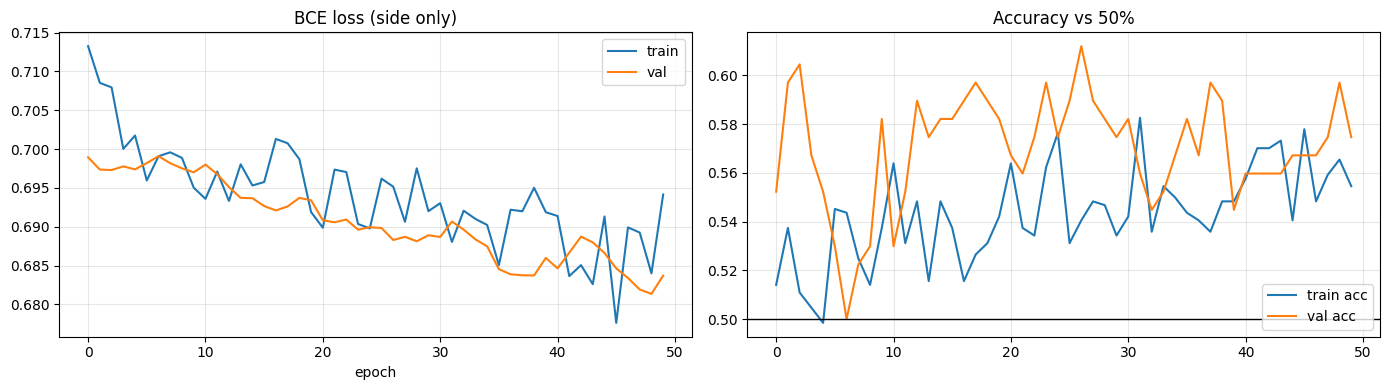

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("BCE loss (side only)")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
if "accuracy" in history.history:
    axes[1].plot(history.history["accuracy"], label="train acc")
    axes[1].plot(history.history["val_accuracy"], label="val acc")
    axes[1].axhline(0.5, color="black", linewidth=1)
    axes[1].set_title("Accuracy vs 50%")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Session backtest (test tail)

One trade per session: long/short at **open**, exit at **session close**. **touch_win** = predicted extreme was traded or exceeded. Equity is not the ranking metric.


In [99]:
pred = test_eval["pred"]
trades = []
equity = 1.0
curve = []
for i, row in enumerate(meta_test.itertuples()):
    side = 1 if pred[i] > 0 else -1
    ret = side * (row.close / row.open - 1.0)
    equity *= 1.0 + ret
    mfe = row.up_ext if side == 1 else row.dn_ext
    mae_adv = row.dn_ext if side == 1 else row.up_ext
    trades.append(
        {
            "session": row.session,
            "open_time": row.open_time,
            "close_time": row.close_time,
            "side": "long" if side == 1 else "short",
            "open": row.open,
            "close": row.close,
            "ret": ret,
            "pred_dom": float(pred[i]),
            "true_dom": float(row.y_dom),
            "touch_win": bool(
                (pred[i] > 0 and row.high >= row.open * (1.0 + pred[i]))
                or (pred[i] < 0 and row.low <= row.open * (1.0 + pred[i]))
            ),
            "dom_side": np.sign(pred[i]) == np.sign(row.y_dom),
            "mfe": mfe,
            "mae_adverse": mae_adv,
        }
    )
    curve.append((row.close_time, equity))

trades_df = pd.DataFrame(trades)
print(f"trades={len(trades_df)}  final_equity={equity:.4f}")
print(f"win_rate close={(trades_df['ret'] > 0).mean():.3f}  mean_ret={trades_df['ret'].mean():.5f}")
print(f"touch_win (pred high/low reached or exceeded)={trades_df['touch_win'].mean():.3f}")
print(f"dom_side (bigger wick)={trades_df['dom_side'].mean():.3f}")
print(f"longs={(trades_df['side']=='long').sum()}  shorts={(trades_df['side']=='short').sum()}")
print(trades_df.groupby("session")["ret"].agg(["count", "mean", "sum"]).to_string())
display(trades_df.head())


trades=134  final_equity=1.0349
win_rate close=0.537  mean_ret=0.00028
touch_win (pred high/low reached or exceeded)=0.343
dom_side (bigger wick)=0.545
longs=90  shorts=44
         count      mean       sum
session                           
london      67 -0.000776 -0.051977
nyc         67  0.001331  0.089207


,session,open_time,close_time,side,open,close,ret,pred_dom,true_dom,touch_win,dom_side,mfe,mae_adverse
0,london,2026-01-26 09:00:00+00:00,2026-01-26 14:25:00+00:00,long,688.62,690.48,0.002701,0.005415,0.002701,False,True,0.002701,0.002396
1,nyc,2026-01-26 14:30:00+00:00,2026-01-26 20:55:00+00:00,long,690.47,692.71,0.003244,0.005415,0.005301,False,True,0.005301,0.000797
2,london,2026-01-27 09:00:00+00:00,2026-01-27 14:25:00+00:00,long,694.45,694.18,-0.000389,0.005415,0.001224,False,True,0.001224,0.000734
3,nyc,2026-01-27 14:30:00+00:00,2026-01-27 20:55:00+00:00,short,694.18,695.54,-0.001959,-0.005415,0.003385,False,False,0.000879,0.003385
4,london,2026-01-28 09:00:00+00:00,2026-01-28 14:25:00+00:00,long,697.50,697.06,-0.000631,0.005415,0.002093,False,True,0.002093,0.001348


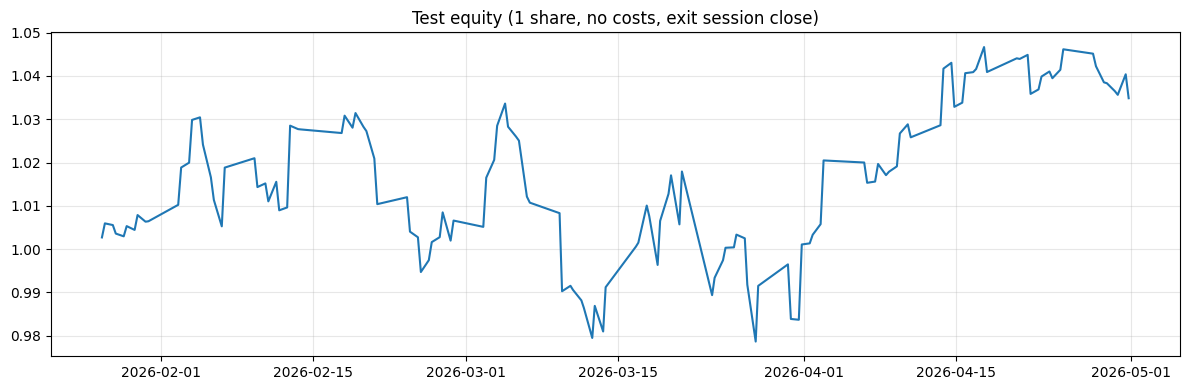

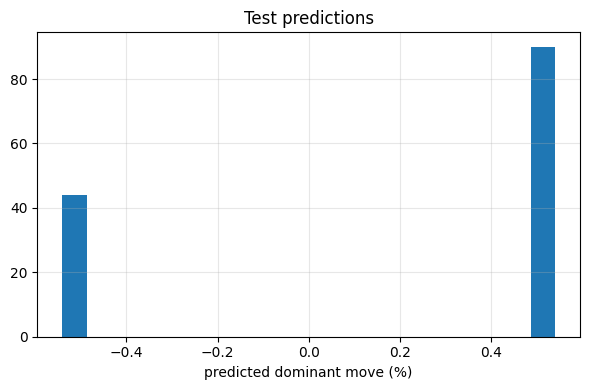

In [100]:
if curve:
    eq = pd.Series({t: e for t, e in curve})
    plt.figure(figsize=(12, 4))
    plt.plot(eq.index, eq.values)
    plt.title("Test equity (1 share, no costs, exit session close)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(6, 4))
plt.hist(trades_df["pred_dom"] * 100, bins=20)
plt.xlabel("predicted dominant move (%)")
plt.title("Test predictions")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [101]:
def dump_scaler(scaler: StandardScaler, path: Path):
    payload = {
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist(),
        "var": scaler.var_.tolist(),
        "n_features_in": int(scaler.n_features_in_),
    }
    path.write_text(json.dumps(payload, indent=2))


model.save(MODEL_PATH)
dump_scaler(feature_scaler, SCALER_PATH)
print(f"saved {MODEL_PATH}")
print(f"saved {SCALER_PATH}")


saved c:\Mario\Projects\MoneyTalk\Trading ML\Trading-for-Dummies-test-\Mario\models\lstm\model.h5
saved c:\Mario\Projects\MoneyTalk\Trading ML\Trading-for-Dummies-test-\Mario\models\lstm\scaler.json
